Index(['Visitor_ID', 'Age', 'Gender', 'Region', 'Visit_Date', 'Disease_Type',
       'Diagnosis_Date', 'Severity', 'Treatment_Plan', 'Treatment_Outcome',
       'Medication_Name', 'Medication_Category', 'Dosage',
       'Treatment_Duration', 'Examination_Item', 'Examination_Result',
       'Reference_Range', 'Weight_kg', 'Height_cm', 'Smoking_Status',
       'Alcohol_Status', 'Family_History'],
      dtype='object')


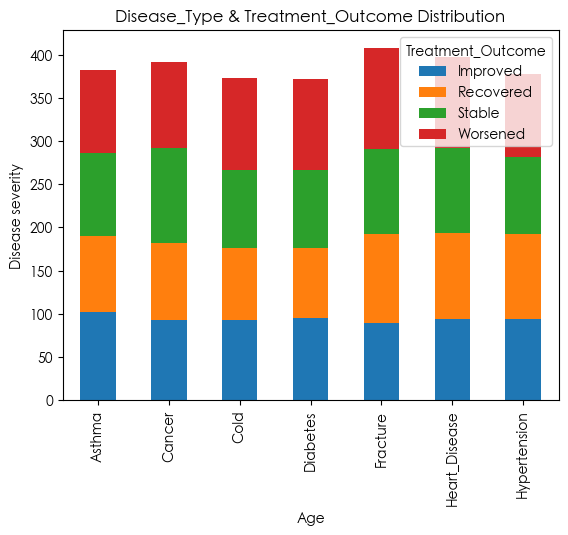

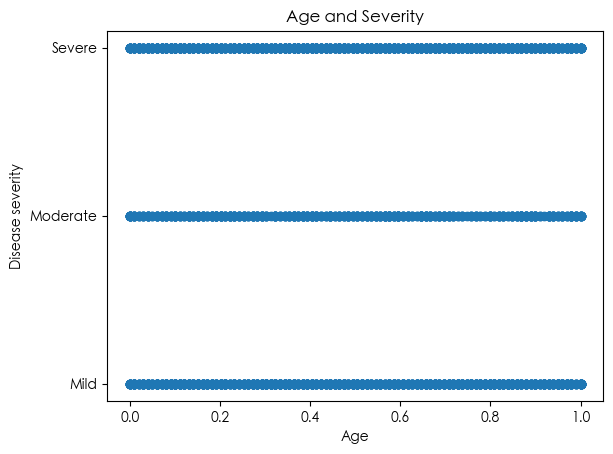

In [4]:
# Data Cleaning Rules
# 1. Data Loading: Load the dataset with pandas and check its basic structure and data types
# 2. Check for missing values, drop rows with missing values, and record the number of deleted rows
# 3. Add two columns: "Diagnosis_Delay" and "Illness_Duration", then remove invalid data
# 4. Check for duplicate values and remove duplicates
# 5. Normalize the data in columns ['Age', 'Weight_kg', 'Height_cm']
# 6. Save the cleaned data

# Data Labeling Specifications
# 1. Data Source: Record the data source, including dataset name, acquisition date and provider
# 2. Data Description: Provide detailed descriptions, including column definitions, units and value ranges
# 3. Feature Selection: Identify the most predictive features for the target variable
# 4. Target Variable Definition: Select the appropriate target variable based on business requirements and data characteristics
# 5. Data Splitting: Split the dataset into training and test sets, typically with an 80/20 ratio, for model training and evaluation
# 6. Save the processed data and record the file path and filename
# 7. Documentation of Data Cleaning and Labeling Specifications

import pandas as pd

data = pd.read_csv('4_medical_data.csv')
print(data.columns)
data['Visit_Date'] = pd.to_datetime(data['Visit_Date'])
data['Diagnosis_Date'] = pd.to_datetime(data['Diagnosis_Date'])
data.rename(columns={'Visitor_ID':'Patient_ID'})

from datetime import datetime
data['Diagnosis_Delay'] = (data['Diagnosis_Date'] - data['Visit_Date']).dt.days
data['Illness_Duration'] = (datetime(2024, 9, 1) - data['Diagnosis_Date']).dt.days

data = data[(data['Diagnosis_Delay'] >= 0) & (data['Age']>0) & (data['Age']<120)]
# print(data.describe())

data.drop_duplicates(inplace=True)

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
columns_to_normalize = ['Age', 'Weight_kg', 'Height_cm']
data[columns_to_normalize] = scaler.fit_transform(data[columns_to_normalize])

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

treamment_outcome_distribution = data.groupby('Disease_Type')['Treatment_Outcome'].value_counts().unstack()

plt.rcParams['font.sans-serif'] = ['STHeiti']  
plt.rcParams['axes.unicode_minus'] = False    

treamment_outcome_distribution.plot(kind='bar', stacked=True)
plt.title('Disease_Type & Treatment_Outcome Distribution')
plt.xlabel('Age')
plt.ylabel('Disease severity')
plt.show()

plt.scatter(data['Age'], data['Severity'])
plt.title('Age and Severity')
plt.xlabel('Age')
plt.ylabel('Disease severity')
data.to_csv('4_medical_data_cleaned.csv', index=False)